# 🏗️ Drone Video → Facade Orthophoto Pipeline
Extracts frames from a drone video, stitches them into a flat 2D facade map, and optionally corrects perspective.

**Stack:** OpenCV · NumPy · Matplotlib (all free, CPU-only)

## 0. Install dependencies

In [1]:
!pip install opencv-python-headless numpy matplotlib tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.2/46.2 MB 12.2 MB/s  0:00:03m0:00:0100:01


## 1. Config — set your paths and tuning params here

In [11]:
from pathlib import Path

# ── INPUT ──────────────────────────────────────────────────────────────────
VIDEO_PATH = Path("short.mp4")   # ← change this

# ── OUTPUT ─────────────────────────────────────────────────────────────────
FRAMES_DIR  = Path("frames")                 # extracted frames go here
OUTPUT_DIR  = Path("output")
STITCH_OUT  = OUTPUT_DIR / "facade_stitch.jpg"
ORTHO_OUT   = OUTPUT_DIR / "facade_ortho.jpg"

# ── FRAME EXTRACTION ───────────────────────────────────────────────────────
FRAME_STEP  = 3   # extract every Nth frame (lower = more frames, slower stitch)
MAX_FRAMES  = 120   # cap total frames to keep memory reasonable on CPU
RESIZE_W    = 1280 # resize each frame to this width before stitching

# ── STITCHER ───────────────────────────────────────────────────────────────
# 'SCANS' mode = flat/planar surfaces (best for facades)
# 'PANORAMA' mode = for curved/360° sweeps
STITCH_MODE = "SCANS"  # or "PANORAMA"

FRAMES_DIR.mkdir(exist_ok=True)
OUTPUT_DIR.mkdir(exist_ok=True)

print(f"Video:  {VIDEO_PATH}")
print(f"Mode:   {STITCH_MODE}  |  frame step: {FRAME_STEP}  |  max frames: {MAX_FRAMES}")

Video:  short.mp4
Mode:   SCANS  |  frame step: 3  |  max frames: 120


## 2. Extract frames from video

Video: 658 frames @ 59.7 fps  (11.0s)


Extracting:   0%|          | 0/120 [00:00<?, ?it/s]

Extracting: 100%|██████████| 120/120 [00:00<00:00, 215.69it/s]


Saved 120 frames → frames


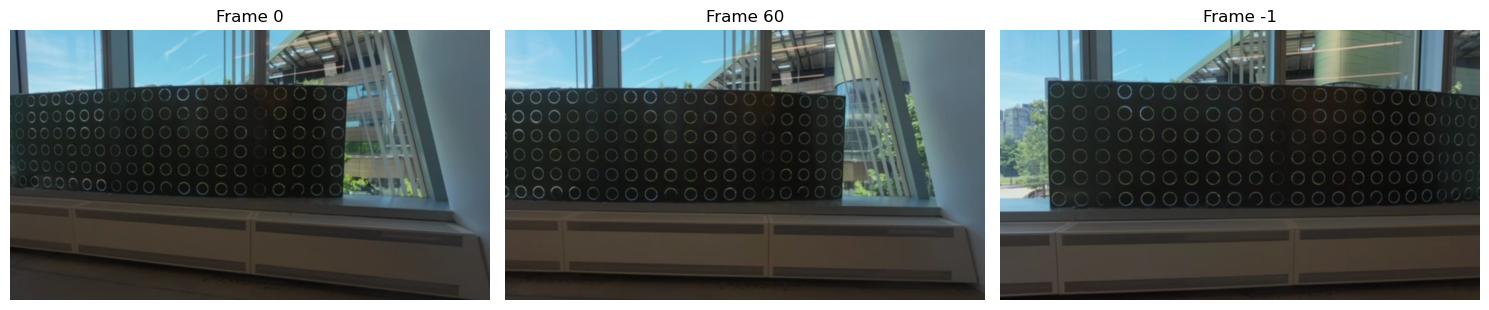

In [12]:
import cv2
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt

def extract_frames(video_path, out_dir, step=10, max_frames=80, resize_w=1280):
    """Extract every `step`-th frame, resize, save as JPEG."""
    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        raise FileNotFoundError(f"Cannot open video: {video_path}")

    total    = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    fps      = cap.get(cv2.CAP_PROP_FPS)
    duration = total / fps if fps else 0
    print(f"Video: {total} frames @ {fps:.1f} fps  ({duration:.1f}s)")

    saved, idx = 0, 0
    paths = []

    pbar = tqdm(total=min(total // step, max_frames), desc="Extracting")
    while saved < max_frames:
        ret, frame = cap.read()
        if not ret:
            break
        if idx % step == 0:
            h, w = frame.shape[:2]
            scale = resize_w / w
            frame = cv2.resize(frame, (resize_w, int(h * scale)))
            p = out_dir / f"frame_{saved:04d}.jpg"
            cv2.imwrite(str(p), frame, [cv2.IMWRITE_JPEG_QUALITY, 90])
            paths.append(str(p))
            saved += 1
            pbar.update(1)
        idx += 1
    pbar.close()
    cap.release()
    print(f"Saved {saved} frames → {out_dir}")
    return paths

frame_paths = extract_frames(VIDEO_PATH, FRAMES_DIR, FRAME_STEP, MAX_FRAMES, RESIZE_W)

# Quick preview — first, middle, last
preview_idx = [0, len(frame_paths)//2, -1]
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, i in zip(axes, preview_idx):
    img = cv2.cvtColor(cv2.imread(frame_paths[i]), cv2.COLOR_BGR2RGB)
    ax.imshow(img)
    ax.set_title(f"Frame {i}")
    ax.axis("off")
plt.tight_layout()
plt.show()

## 3. Stitch frames → raw panorama

> **SCANS mode** (recommended for facades): assumes a planar surface, uses affine/homography warping — gives minimal distortion on flat walls.  
> **PANORAMA mode**: better if the drone panned in an arc around the building.

Stitching 120 images in SCANS mode… (may take 1-3 min on CPU)
✅ Success


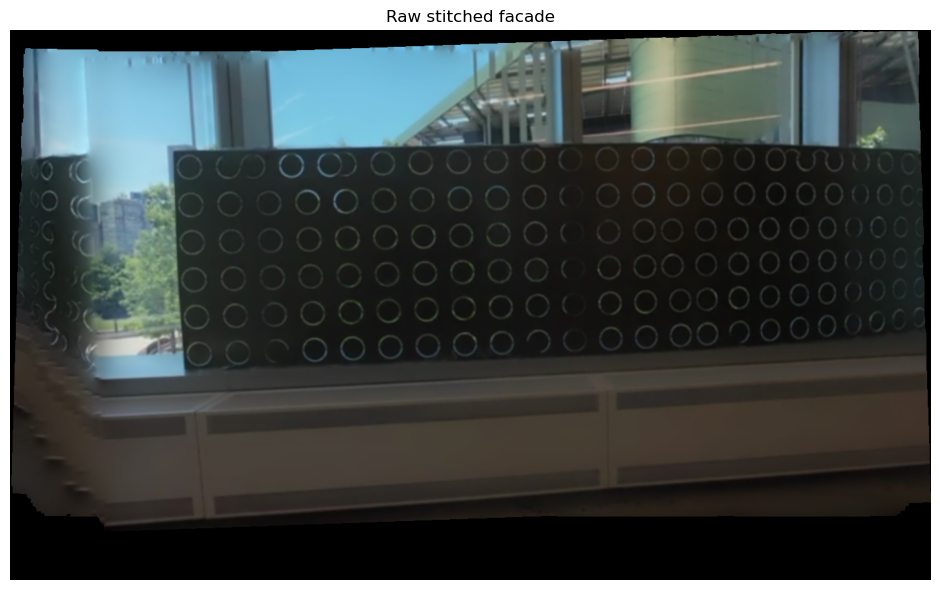

Saved → output/facade_stitch.jpg  |  size: 1424×850 px


In [13]:
def load_images(paths):
    imgs = [cv2.imread(p) for p in paths]
    missing = [p for p, im in zip(paths, imgs) if im is None]
    if missing:
        raise ValueError(f"Could not load: {missing}")
    return imgs

def stitch(frame_paths, mode="SCANS"):
    imgs = load_images(frame_paths)
    mode_flag = cv2.Stitcher_SCANS if mode == "SCANS" else cv2.Stitcher_PANORAMA
    stitcher  = cv2.Stitcher.create(mode_flag)

    # Tune feature detector for better accuracy on building textures
    # (ORB is fast + free; SIFT is slower but more robust — uncomment if needed)
    # stitcher.setFeaturesFinder(cv2.SIFT.create())

    print(f"Stitching {len(imgs)} images in {mode} mode… (may take 1-3 min on CPU)")
    status, result = stitcher.stitch(imgs)

    status_map = {
        cv2.Stitcher_OK:             "✅ Success",
        cv2.Stitcher_ERR_NEED_MORE_IMGS: "❌ Need more images — reduce FRAME_STEP",
        cv2.Stitcher_ERR_HOMOGRAPHY_EST_FAIL: "❌ Homography failed — try fewer frames or different STITCH_MODE",
        cv2.Stitcher_ERR_CAMERA_PARAMS_ADJUST_FAIL: "❌ Camera params failed",
    }
    print(status_map.get(status, f"❌ Unknown error (code {status})"))
    if status != cv2.Stitcher_OK:
        return None
    return result

panorama = stitch(frame_paths, mode=STITCH_MODE)

if panorama is not None:
    cv2.imwrite(str(STITCH_OUT), panorama)
    plt.figure(figsize=(18, 6))
    plt.imshow(cv2.cvtColor(panorama, cv2.COLOR_BGR2RGB))
    plt.title("Raw stitched facade")
    plt.axis("off")
    plt.tight_layout()
    plt.show()
    print(f"Saved → {STITCH_OUT}  |  size: {panorama.shape[1]}×{panorama.shape[0]} px")

## 4. Crop black borders
The stitcher often leaves black triangles at the edges — this trims them.

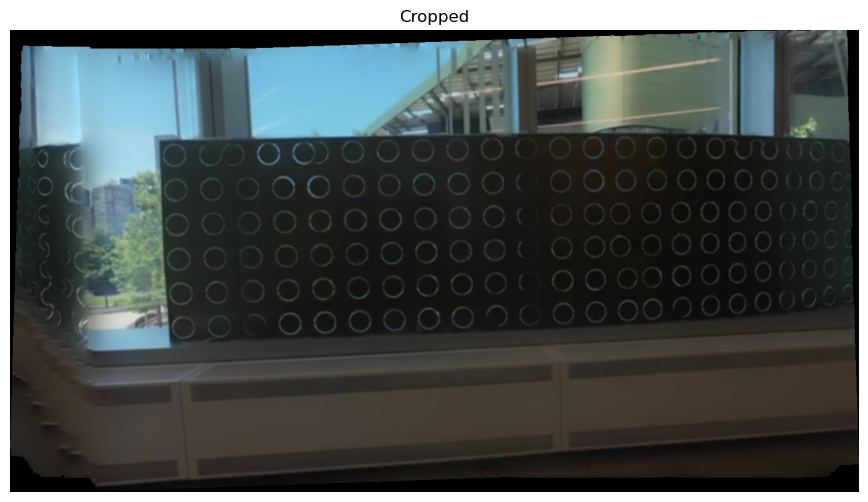

Cropped size: 1422×774 px


In [14]:
def crop_black_borders(img, threshold=5):
    """Crop largest rectangle with no black border pixels."""
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    _, mask = cv2.threshold(gray, threshold, 255, cv2.THRESH_BINARY)
    coords = cv2.findNonZero(mask)
    if coords is None:
        return img
    x, y, w, h = cv2.boundingRect(coords)
    return img[y:y+h, x:x+w]

if panorama is not None:
    panorama_cropped = crop_black_borders(panorama)
    plt.figure(figsize=(18, 6))
    plt.imshow(cv2.cvtColor(panorama_cropped, cv2.COLOR_BGR2RGB))
    plt.title("Cropped")
    plt.axis("off")
    plt.show()
    print(f"Cropped size: {panorama_cropped.shape[1]}×{panorama_cropped.shape[0]} px")

## 5. (Optional) Perspective / keystone correction

If the facade still looks trapezoidal (drone wasn't perfectly parallel to the wall), use this cell to manually define the four corners of the facade plane and warp it to a flat rectangle.

**Instructions:** Run the cell, click the 4 corners of the facade in order:  
`top-left → top-right → bottom-right → bottom-left`  
then close the window.

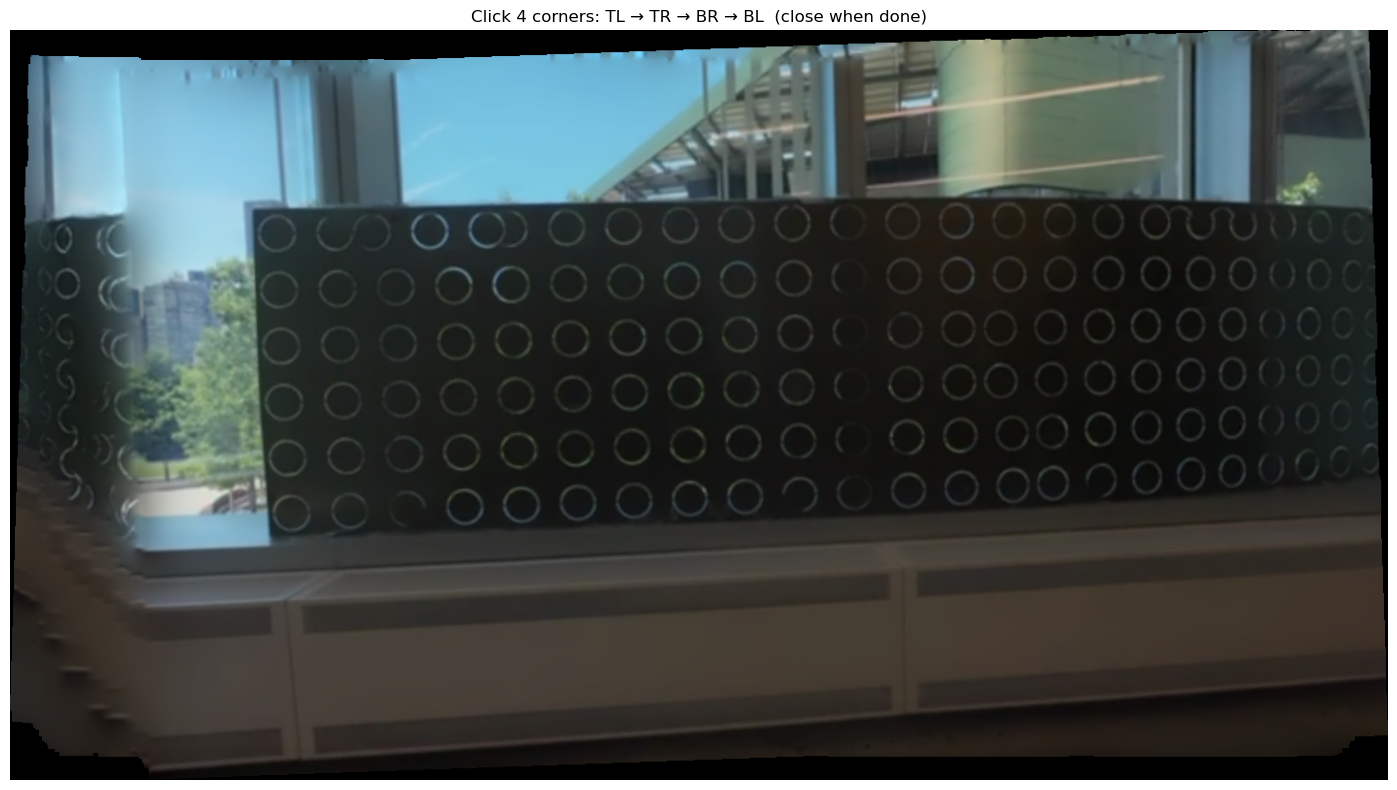

Only 0 points picked — skipping correction.


In [15]:
import matplotlib.patches as patches
from matplotlib.widgets import Button

# ── Interactive 4-point picker ──────────────────────────────────────────────
points = []

def pick_corners(img_bgr):
    """Click 4 corners (TL, TR, BR, BL) on the image."""
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    fig, ax = plt.subplots(figsize=(16, 8))
    ax.imshow(img_rgb)
    ax.set_title("Click 4 corners: TL → TR → BR → BL  (close when done)")
    ax.axis("off")

    clicked = []
    markers = []
    labels  = ["TL", "TR", "BR", "BL"]

    def on_click(event):
        if event.inaxes != ax or len(clicked) >= 4:
            return
        x, y = int(event.xdata), int(event.ydata)
        clicked.append((x, y))
        n = len(clicked) - 1
        m = ax.plot(x, y, "ro", markersize=8)[0]
        ax.annotate(labels[n], (x, y), color="red", fontsize=12,
                    xytext=(8, 8), textcoords="offset points")
        markers.append(m)
        fig.canvas.draw()
        if len(clicked) == 4:
            print("4 corners picked — close the window to continue.")

    fig.canvas.mpl_connect("button_press_event", on_click)
    plt.tight_layout()
    plt.show()
    return clicked

def perspective_correct(img_bgr, src_pts, output_w=None, output_h=None):
    """Warp src_pts (TL,TR,BR,BL) to a flat rectangle."""
    src = np.array(src_pts, dtype=np.float32)

    # Auto-size output from the picked quadrilateral
    if output_w is None:
        output_w = int(max(np.linalg.norm(src[1]-src[0]),   # top edge
                           np.linalg.norm(src[2]-src[3])))  # bottom edge
    if output_h is None:
        output_h = int(max(np.linalg.norm(src[3]-src[0]),   # left edge
                           np.linalg.norm(src[2]-src[1])))  # right edge

    dst = np.array([[0, 0], [output_w-1, 0],
                    [output_w-1, output_h-1], [0, output_h-1]], dtype=np.float32)
    M = cv2.getPerspectiveTransform(src, dst)
    warped = cv2.warpPerspective(img_bgr, M, (output_w, output_h),
                                 flags=cv2.INTER_LANCZOS4)
    return warped

# ── Run ────────────────────────────────────────────────────────────────────
if panorama is not None:
    src_pts = pick_corners(panorama_cropped)

    if len(src_pts) == 4:
        ortho = perspective_correct(panorama_cropped, src_pts)
        cv2.imwrite(str(ORTHO_OUT), ortho)

        plt.figure(figsize=(16, 8))
        plt.imshow(cv2.cvtColor(ortho, cv2.COLOR_BGR2RGB))
        plt.title("Perspective-corrected facade orthophoto")
        plt.axis("off")
        plt.tight_layout()
        plt.show()
        print(f"Saved → {ORTHO_OUT}  |  size: {ortho.shape[1]}×{ortho.shape[0]} px")
    else:
        print(f"Only {len(src_pts)} points picked — skipping correction.")

## 6. (Optional) Auto perspective correction via line detection

If the facade has strong vertical/horizontal lines (windows, floors), this auto-detects vanishing lines and corrects perspective without manual clicking.

Detected 11 vertical, 33 horizontal lines


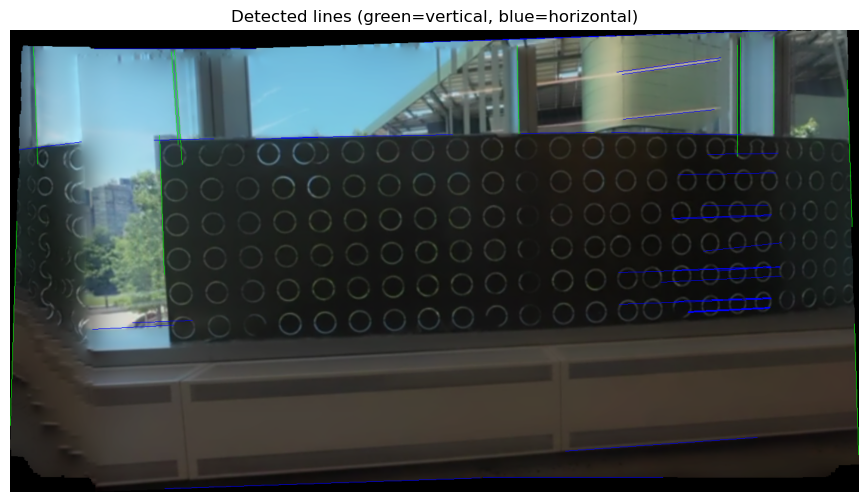

Mean vertical skew: 3.89°


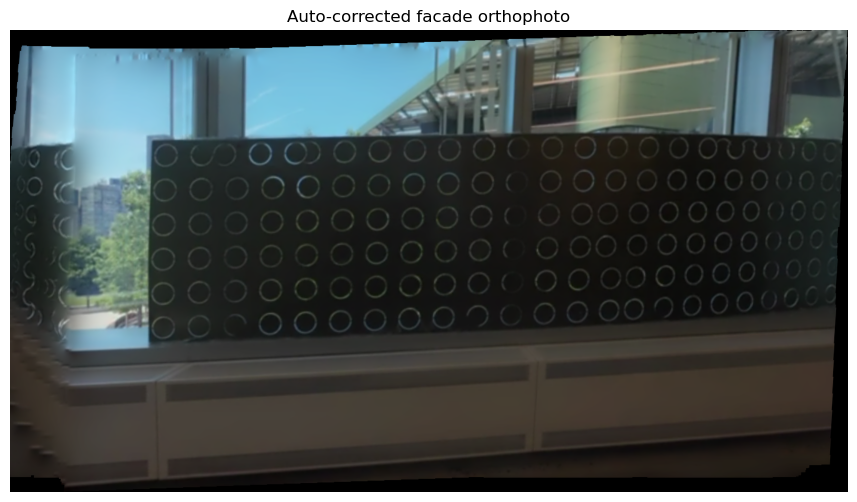

Saved → output/facade_auto_ortho.jpg


In [16]:
def auto_perspective_correct(img_bgr, debug=True):
    """
    Uses Hough line detection to find dominant vertical/horizontal lines
    and computes a correction homography.
    Works best on facades with regular window grids.
    """
    gray  = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    edges = cv2.Canny(gray, 50, 150, apertureSize=3)
    lines = cv2.HoughLinesP(edges, 1, np.pi/180,
                             threshold=100, minLineLength=100, maxLineGap=20)
    if lines is None:
        print("No lines detected — try manual correction (Cell 5).")
        return img_bgr

    # Separate into near-vertical and near-horizontal
    verticals, horizontals = [], []
    for x1,y1,x2,y2 in lines[:,0]:
        angle = np.degrees(np.arctan2(y2-y1, x2-x1))
        if abs(angle) < 20 or abs(angle) > 160:
            horizontals.append((x1,y1,x2,y2))
        elif 70 < abs(angle) < 110:
            verticals.append((x1,y1,x2,y2))

    print(f"Detected {len(verticals)} vertical, {len(horizontals)} horizontal lines")

    if debug:
        dbg = img_bgr.copy()
        for x1,y1,x2,y2 in verticals:   cv2.line(dbg,(x1,y1),(x2,y2),(0,255,0),1)
        for x1,y1,x2,y2 in horizontals: cv2.line(dbg,(x1,y1),(x2,y2),(255,0,0),1)
        plt.figure(figsize=(16,6))
        plt.imshow(cv2.cvtColor(dbg, cv2.COLOR_BGR2RGB))
        plt.title("Detected lines (green=vertical, blue=horizontal)")
        plt.axis("off")
        plt.show()

    # Fit mean angle of vertical lines → compute shear correction
    if len(verticals) > 5:
        angles = [np.degrees(np.arctan2(x2-x1, y2-y1)) for x1,y1,x2,y2 in verticals]
        mean_skew = np.median(angles)
        print(f"Mean vertical skew: {mean_skew:.2f}°")

        h, w = img_bgr.shape[:2]
        # Shear matrix to correct skew
        shear = np.float32([[1, -np.tan(np.radians(mean_skew)), 0],
                             [0,  1,                             0]])
        corrected = cv2.warpAffine(img_bgr, shear, (w, h), flags=cv2.INTER_LANCZOS4)
        return corrected

    print("Not enough verticals for auto-correction — use manual picker (Cell 5).")
    return img_bgr


if panorama is not None:
    auto_ortho = auto_perspective_correct(panorama_cropped, debug=True)
    auto_ortho = crop_black_borders(auto_ortho)

    plt.figure(figsize=(16, 6))
    plt.imshow(cv2.cvtColor(auto_ortho, cv2.COLOR_BGR2RGB))
    plt.title("Auto-corrected facade orthophoto")
    plt.axis("off")
    plt.show()

    auto_out = OUTPUT_DIR / "facade_auto_ortho.jpg"
    cv2.imwrite(str(auto_out), auto_ortho)
    print(f"Saved → {auto_out}")

## 7. Export summary

In [17]:
print("=" * 50)
print("OUTPUT FILES")
print("=" * 50)
for f in OUTPUT_DIR.glob("*.jpg"):
    sz = f.stat().st_size / 1e6
    img = cv2.imread(str(f))
    dims = f"{img.shape[1]}×{img.shape[0]}" if img is not None else "?"
    print(f"  {f.name:<30} {dims} px   {sz:.1f} MB")

OUTPUT FILES
  facade_auto_ortho.jpg          1403×774 px   0.2 MB
  facade_stitch.jpg              1424×850 px   0.2 MB


---
## Troubleshooting

| Symptom | Fix |
|---|---|
| `ERR_NEED_MORE_IMGS` | Reduce `FRAME_STEP` (e.g. 5 instead of 10) |
| `ERR_HOMOGRAPHY_EST_FAIL` | Frames overlap too little — slower drone pass, or switch to `PANORAMA` mode |
| Black seams / ghosting | Add `stitcher.setSeamEstimator(...)` or try SIFT instead of ORB |
| Barrel distortion | Correct lens distortion before stitching using `cv2.undistort()` with your drone's camera matrix |
| Very slow | Reduce `MAX_FRAMES` to 40–50, or `RESIZE_W` to 960 |
| Still trapezoidal | Use Cell 5 (manual 4-point pick) for precise perspective correction |